In [1]:
import sys
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset, ConcatDataset
import torch
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import os
import torch.nn.functional as F
from torch import nn
from cvae_model import CVAE, cvae_loss
from torch.utils.data import Subset
import numpy as np

vae_path = "/home/benjiy/repo/Verified-Synthetic-Data/MNIST"
sys.path.append(vae_path)

In [ ]:
sample_size = 5000
latent_dim = 20
label_dim = 10
batch_size = 128
epochs = 200
lr = 1e-3



In [ ]:
def one_hot(labels, num_classes=10):
    return F.one_hot(labels, num_classes).float()

In [49]:
############################ real data training ############################

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
# Load MNIST
transform = transforms.ToTensor()
full_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_dataset = Subset(full_dataset, range(sample_size))
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Initialize model
model = CVAE(latent_dim=latent_dim, label_dim=label_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# One-hot encoding helper


best_train_loss = float('inf')
patience = 5
trigger_times = 0

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x = x.view(-1, 784).to(device)
        y = one_hot(y).to(device)

        optimizer.zero_grad()
        recon_x, mu, logvar = model(x, y)
        loss = cvae_loss(recon_x, x, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_loss:.4f}")

    # Early stopping based on training loss
    if avg_loss < best_train_loss:
        best_train_loss = avg_loss
        trigger_times = 0
    else:
        trigger_times += 1
        print(f"EarlyStopping counter: {trigger_times} out of {patience}")
        if trigger_times >= patience:
            print("Early stopping triggered.")
            break


Epoch [1/200], Train Loss: 287.3867
Epoch [2/200], Train Loss: 203.6801
Epoch [3/200], Train Loss: 181.6078
Epoch [4/200], Train Loss: 164.1029
Epoch [5/200], Train Loss: 154.0491
Epoch [6/200], Train Loss: 146.9774
Epoch [7/200], Train Loss: 141.7934
Epoch [8/200], Train Loss: 137.3640
Epoch [9/200], Train Loss: 133.5763
Epoch [10/200], Train Loss: 130.4121
Epoch [11/200], Train Loss: 127.6832
Epoch [12/200], Train Loss: 125.2275
Epoch [13/200], Train Loss: 123.5801
Epoch [14/200], Train Loss: 121.8810
Epoch [15/200], Train Loss: 120.5018
Epoch [16/200], Train Loss: 119.0569
Epoch [17/200], Train Loss: 117.7134
Epoch [18/200], Train Loss: 116.7374
Epoch [19/200], Train Loss: 115.6602
Epoch [20/200], Train Loss: 114.7491
Epoch [21/200], Train Loss: 114.2187
Epoch [22/200], Train Loss: 113.2710
Epoch [23/200], Train Loss: 112.7867
Epoch [24/200], Train Loss: 112.0553
Epoch [25/200], Train Loss: 111.4394
Epoch [26/200], Train Loss: 110.9918
Epoch [27/200], Train Loss: 110.5948
Epoch [28/

In [50]:
# Get the current working directory
model_save_path = os.path.join(os.getcwd(), "model_saved", f"cvae_0_{sample_size}.pth")
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)
torch.save(model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

Model saved to /home/benjiy/repo/Verified-Synthetic-Data/MNIST/model_saved/cvae_0_5000.pth


In [5]:
############################ generate synthetic data ############################

def generate_images_in_batches(model, total_samples, num_classes, batch_size=10000):
    model.eval()
    device = next(model.parameters()).device  # Get device from model
    generated_images = []
    all_labels = []

    for start in range(0, total_samples, batch_size):
        end = min(start + batch_size, total_samples)
        batch_size_actual = end - start

        # Generate z and y
        z = torch.randn(batch_size_actual, model.latent_dim,device=device)
        y = torch.arange(num_classes,device=device).repeat_interleave(total_samples // num_classes)[start:end]
        y_onehot = F.one_hot(y, num_classes=num_classes).float().to(device)

        with torch.no_grad():
            imgs = model.decode(z, y_onehot).view(-1, 1, 28, 28).cpu()
            generated_images.append(imgs)
            all_labels.append(y.cpu())

    images = torch.cat(generated_images, dim=0)
    labels = torch.cat(all_labels, dim=0)
    return images, labels

In [6]:
model_load_path = "/home/benjiy/repo/Verified-Synthetic-Data/MNIST/model_saved/cvae_0_60000.pth"

model = CVAE(latent_dim=latent_dim, label_dim=label_dim)
model.load_state_dict(torch.load(model_load_path))
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
# large sample size for training


synthetic_gen_size = 60000
# large sample size for training

gen_imgs_before_filter,y_before_filter = generate_images_in_batches(
    model=model,
    total_samples=synthetic_gen_size,
    num_classes=10,
    batch_size=10000,
)

data_save_path = os.path.join(os.getcwd(),"data_saved",f"samples_0_{sample_size}.pt")
os.makedirs(os.path.dirname(data_save_path), exist_ok=True)
torch.save({
    'images': gen_imgs_before_filter,    # Tensor, [sample_size, 1, 28, 28]
    'labels': y_before_filter            # Tensor, [sample_size]
    }, data_save_path)

In [ ]:
# Train Discriminator

from discriminator import Discriminator

disc_train_size = 60000
data = torch.load(os.path.join(os.getcwd(), "data_saved","samples_0_60000.pt"))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# real MNIST (60,000）
transform = transforms.ToTensor()
mnist = datasets.MNIST('./data', train=True, download=True, transform=transform)
real_imgs = torch.stack([mnist[i][0] for i in range(disc_train_size)])  # shape: [60000, 1, 28, 28]
real_labels = torch.ones(disc_train_size, 1)  # label = 1

# synthetic data（60,000）

fake_imgs = data['images'][:disc_train_size]  # shape: [60000, 1, 28, 28]
fake_labels = torch.zeros(disc_train_size, 1)  # label = 0

X_all = torch.cat([real_imgs, fake_imgs], dim=0)
y_all = torch.cat([real_labels, fake_labels], dim=0)

perm = torch.randperm(len(X_all))
X_all = X_all[perm]
y_all = y_all[perm]


disc_dataset = TensorDataset(X_all, y_all)
disc_loader = DataLoader(disc_dataset, batch_size=128, shuffle=True)

discriminator = Discriminator().to(device)
optimizer = torch.optim.Adam(discriminator.parameters(), lr=1e-3)
loss_fn = nn.BCELoss()

for epoch in range(10):

    discriminator.train()
    total_loss = 0
    correct = 0
    total = 0

    for x_batch, y_batch in disc_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        preds = discriminator(x_batch)
        loss = loss_fn(preds, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        predicted = (preds > 0.5).float()
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

    acc = correct / total
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}, Accuracy: {acc*100:.2f}%")


Epoch 1, Loss: 115.4718, Accuracy: 94.84%
Epoch 2, Loss: 40.6286, Accuracy: 98.45%
Epoch 3, Loss: 29.5131, Accuracy: 98.89%
Epoch 4, Loss: 23.6737, Accuracy: 99.07%
Epoch 5, Loss: 19.8625, Accuracy: 99.23%
Epoch 6, Loss: 17.9438, Accuracy: 99.31%
Epoch 7, Loss: 13.9555, Accuracy: 99.44%
Epoch 8, Loss: 14.9283, Accuracy: 99.42%
Epoch 9, Loss: 12.4548, Accuracy: 99.52%
Epoch 10, Loss: 12.8690, Accuracy: 99.49%


In [ ]:
# Save Discriminator
model_save_path = os.path.join(os.getcwd(), "model_saved", f"discriminator_0_1_{disc_train_size}.pth")
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)
torch.save(discrimnator.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

Model saved to /home/benjiy/repo/Verified-Synthetic-Data/MNIST/model_saved/discriminator_0_1_60000.pth


In [36]:

def load_synthetic_data_in_chunks(file_path, batch_size=512):
    """Load synthetic data in chunks to avoid memory issues"""
    data = torch.load(file_path)
    images = data['images']
    labels = data['labels']
    
    # Create DataLoader
    dataset = torch.utils.data.TensorDataset(images, labels)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    return loader
    

############################ filter synthetic data ############################

discriminator_load_path = "/home/benjiy/repo/Verified-Synthetic-Data/MNIST/model_saved/discriminator_0_1_60000.pth"
synthetic_data_load_path = "/home/benjiy/repo/Verified-Synthetic-Data/MNIST/data_saved/samples_0_60000.pt"

discriminator = Discriminator().to(device)
discriminator.load_state_dict(torch.load(discriminator_load_path))
discriminator.eval()


# Use the function
synthetic_loader = load_synthetic_data_in_chunks(synthetic_data_load_path, batch_size=512)

all_probs = []
all_labels = []
all_images = []

with torch.no_grad():
    for batch_images, batch_labels in synthetic_loader:
        batch_images = batch_images.to(device)
        batch_labels = batch_labels.to(device)
        probs = discriminator(batch_images)  # [batch_size, 1], already sigmoid activated
        all_probs.append(probs.cpu())
        all_labels.append(batch_labels.cpu())
        all_images.append(batch_images.cpu())
all_probs = torch.cat(all_probs, dim=0)
all_labels = torch.cat(all_labels, dim=0)
all_images = torch.cat(all_images, dim=0)
# Flatten probs to shape [N]


filter_threshold = np.quantile(all_probs.squeeze().numpy(),0.20)


# Apply mask
filtered_images = all_images[all_probs.squeeze(1) > filter_threshold]
filtered_labels = all_labels[all_probs.squeeze(1) > filter_threshold]

print(f"Selected {filtered_images.shape[0]} samples with p > {filter_threshold}")

# Save to file
torch.save({
    'images': filtered_images,
    'labels': filtered_labels
}, f"data_saved/samples_q20_{0}_{60000}.pt")


print(filtered_images.shape)
print(filtered_labels.shape)

Selected 48000 samples with p > 2.0581279736031632e-12
torch.Size([48000, 1, 28, 28])
torch.Size([48000])


# Plot some digits to check

In [37]:

# Plot 10 random samples for each digit
def plot_10_samples_per_digit(images, labels):
    fig, axes = plt.subplots(10, 10, figsize=(20, 20))
    fig.suptitle("10 Random Samples for Each Digit (0-9)", fontsize=16)
    
    for digit in range(10):
        # Find indices for this digit
        digit_indices = (labels == digit).nonzero(as_tuple=True)[0]
        
        if len(digit_indices) >= 10:
            # Get 10 random samples for this digit
            selected_indices = np.random.choice(digit_indices, 10, replace=False)
            
            for i, idx in enumerate(selected_indices):
                img = images[idx].squeeze()
                axes[digit, i].imshow(img, cmap='gray')
                axes[digit, i].set_title(f'Digit {digit}')
                axes[digit, i].axis('off')
        else:
            # If less than 10 samples for this digit, show what we have
            num_available = min(len(digit_indices), 10)
            if num_available > 0:
                selected_indices = np.random.choice(digit_indices, num_available, replace=False)
                for i, idx in enumerate(selected_indices):
                    img = images[idx].squeeze()
                    axes[digit, i].imshow(img, cmap='gray')
                    axes[digit, i].set_title(f'Digit {digit}')
                    axes[digit, i].axis('off')
            
            # Fill remaining slots with empty plots
            for i in range(num_available, 10):
                axes[digit, i].text(0.5, 0.5, f'Only {num_available} samples', 
                                   ha='center', va='center', fontsize=8)
                axes[digit, i].axis('off')
    
    plt.tight_layout()
    plt.show()

# Plot the samples




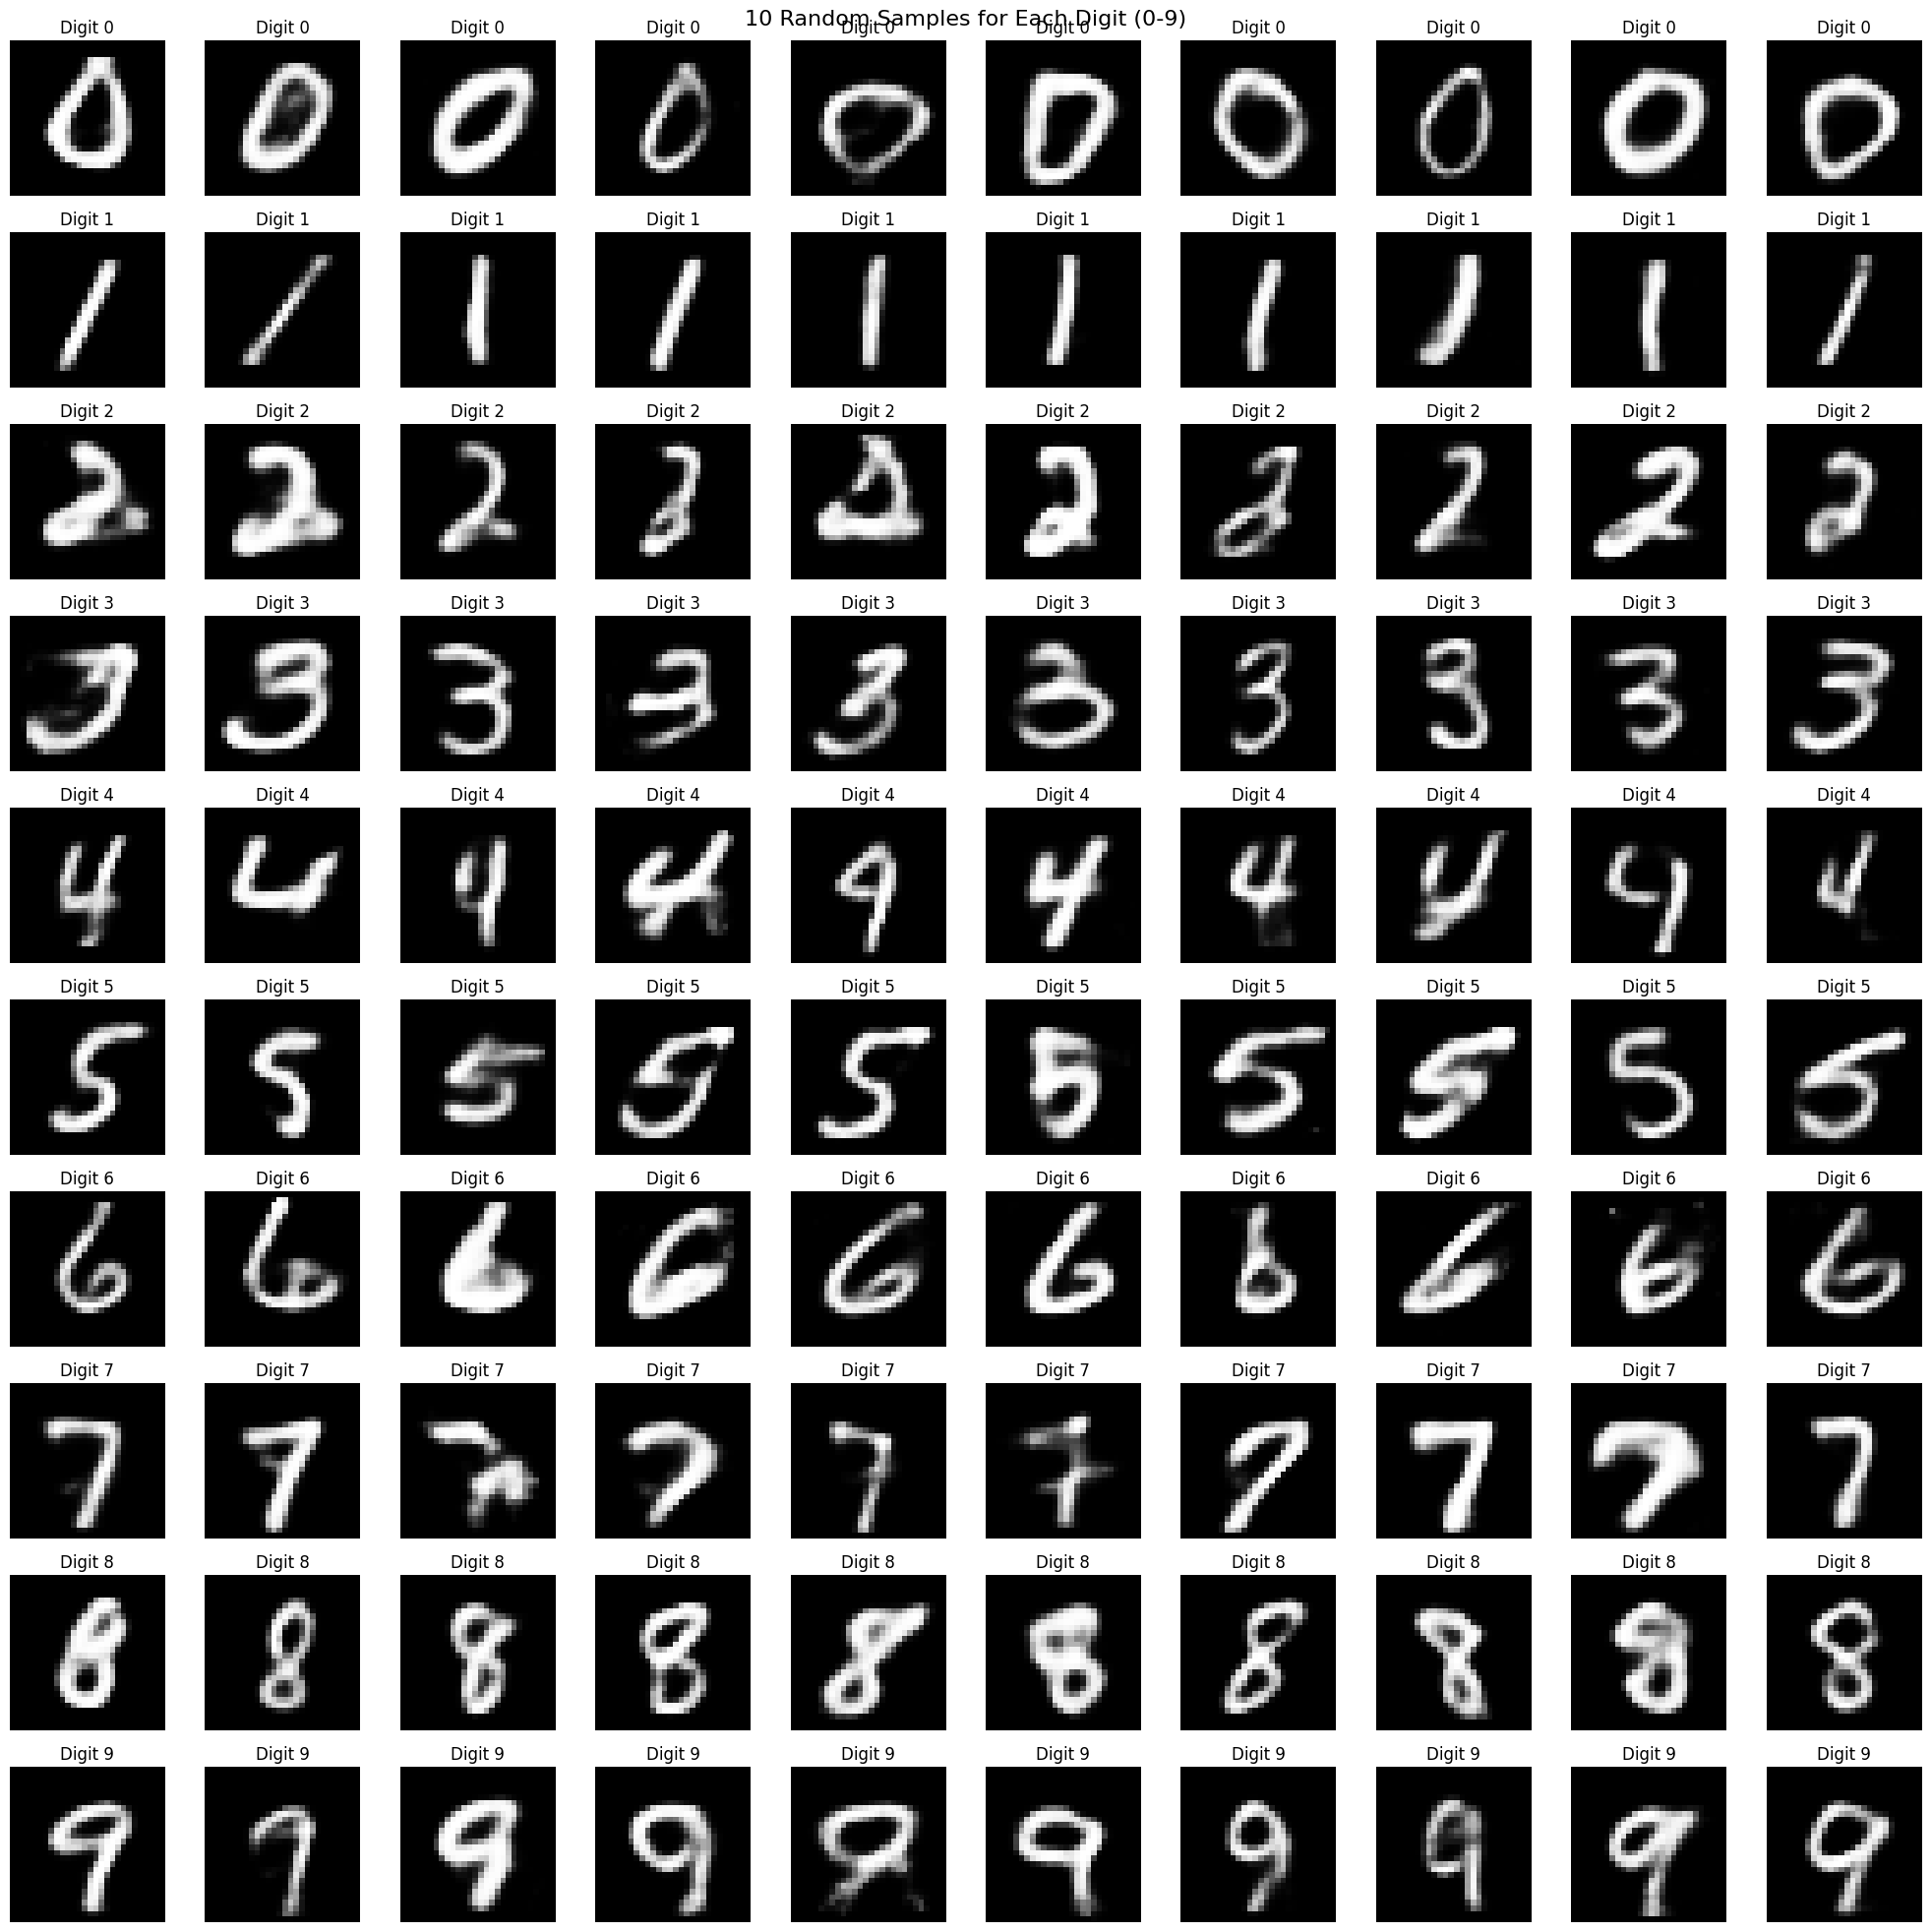

In [38]:
plot_10_samples_per_digit(filtered_images, filtered_labels)

In [47]:
############################ synthetic data retraining ############################

from torch.utils.data import TensorDataset

images = filtered_images  # shape: [N, 1, 28, 28]
labels = filtered_labels  # shape: [N]

print(f"Loaded {images.shape[0]} filtered synthetic samples")

# Preprocess: flatten images and convert labels to one-hot
images = images.view(-1, 784)  # flatten to [N, 784]

# Create dataset and dataloader
dataset = TensorDataset(images, labels)
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Initialize model
model = CVAE(latent_dim=latent_dim, label_dim=label_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

best_train_loss = float('inf')
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x = x.view(-1, 784).to(device)
        y = one_hot(y).to(device)

        optimizer.zero_grad()
        recon_x, mu, logvar = model(x, y)
        loss = cvae_loss(recon_x, x, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_loss:.4f}")

    # Early stopping based on training loss
    if avg_loss < best_train_loss:
        best_train_loss = avg_loss
        trigger_times = 0
    else:
        trigger_times += 1
        print(f"EarlyStopping counter: {trigger_times} out of {patience}")
        if trigger_times >= patience:
            print("Early stopping triggered.")
            break

# save the model to model_saved folder
model_save_path = os.path.join(os.getcwd(), "model_saved", f"cvae_1_{48000}.pth")
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)
torch.save(model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")





Loaded 48000 filtered synthetic samples
Epoch [1/200], Train Loss: 164.7053
Epoch [2/200], Train Loss: 123.8346
Epoch [3/200], Train Loss: 116.9995
Epoch [4/200], Train Loss: 113.7178
Epoch [5/200], Train Loss: 111.8029
Epoch [6/200], Train Loss: 110.4613
Epoch [7/200], Train Loss: 109.4195
Epoch [8/200], Train Loss: 108.7422
Epoch [9/200], Train Loss: 108.0528
Epoch [10/200], Train Loss: 107.5894
Epoch [11/200], Train Loss: 107.1420
Epoch [12/200], Train Loss: 106.8067
Epoch [13/200], Train Loss: 106.4472
Epoch [14/200], Train Loss: 106.1735
Epoch [15/200], Train Loss: 105.9862
Epoch [16/200], Train Loss: 105.6980
Epoch [17/200], Train Loss: 105.5141
Epoch [18/200], Train Loss: 105.3597
Epoch [19/200], Train Loss: 105.1662
Epoch [20/200], Train Loss: 104.9783
Epoch [21/200], Train Loss: 104.8802
Epoch [22/200], Train Loss: 104.7388
Epoch [23/200], Train Loss: 104.6612
Epoch [24/200], Train Loss: 104.4765
Epoch [25/200], Train Loss: 104.4150
Epoch [26/200], Train Loss: 104.3445
Epoch [

In [ ]:
# use the new model to generate synthetic data for evaluation
model.eval()

n_per_class = 60000
num_classes = 10
total_samples = n_per_class * num_classes
latent_dim = model.latent_dim
device = next(model.parameters()).device

z = torch.randn(total_samples, latent_dim).to(device)
y = torch.arange(num_classes).repeat_interleave(n_per_class)
y_onehot = F.one_hot(y, num_classes=num_classes).float().to(device)

with torch.no_grad():
    gen_imgs = model.decode(z, y_onehot).view(-1, 1, 28, 28).cpu()  # shape: [60000, 1, 28, 28]

# save the generated images and labels
save_path = f"data_saved/synthetic_mnist_cvae_filtered_synthetic_model_generated_data_{sample_size}.pt"
torch.save({"images": gen_imgs, "labels": y}, save_path)

In [54]:
############################ Model Evaluation ############################

# # FID
# from FID import calculate_fid_score

# transform = transforms.ToTensor()

# real_ds = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
# ### Synthetic dataset
# synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_{sample_size}_2.pt")
# synthetic_ds = TensorDataset(synthetic['images'], torch.zeros(len(synthetic['images'])))
# fid_value = calculate_fid_score(real_ds, synthetic_ds)
# print(f"FID Score(real data and synthetic data): {fid_value:.2f}")

# ## filtered synthetic data
# synthetic = torch.load(f"data_saved/synthetic_mnist_filtered_pgt{filter_threshold}_{sample_size}.pt")
# synthetic_ds = TensorDataset(synthetic['images'], torch.zeros(len(synthetic['images'])))
# fid_value = calculate_fid_score(real_ds, synthetic_ds)
# print(f"FID Score(real data and filtered synthetic data): {fid_value:.2f}")

# # Synthetic dataset
# synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_filtered_synthetic_model_generated_data_{sample_size}.pt")
# synthetic_ds = TensorDataset(synthetic['images'], torch.zeros(len(synthetic['images'])))
# fid_value = calculate_fid_score(real_ds, synthetic_ds)
# print(f"FID Score(real data and model 2 synthetic data): {fid_value:.2f}")

# Reconstruction Loss

# Load model
model = CVAE(latent_dim=20, label_dim=10).to(device)
model_load_path = "/home/benjiy/repo/Verified-Synthetic-Data/MNIST/model_saved/cvae_0_5000.pth"
model.load_state_dict(torch.load(model_load_path, map_location=device))
model.eval()

# Load test set
test_dataset = datasets.MNIST(root="./data", train=False, transform=transforms.ToTensor())
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# Evaluation
total_loss = 0
total_recon_loss = 0
total_kl = 0
num_samples = 0

with torch.no_grad():
    for x, y in test_loader:
        x = x.view(-1, 784).to(device)
        y = F.one_hot(y, num_classes=10).float().to(device)

        recon_x, mu, logvar = model(x, y)
        BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
        KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss = BCE + KLD

        total_loss += loss.item()
        total_recon_loss += BCE.item()
        total_kl += KLD.item()
        num_samples += x.size(0)

print(f"Test Set Results,", os.path.basename(model_load_path))
print(f"  Avg CVAE Loss: {total_loss / num_samples:.4f}")
print(f"  Avg Reconstruction (BCE) Loss: {total_recon_loss / num_samples:.4f}")
print(f"  Avg KL Divergence: {total_kl / num_samples:.4f}")

# get the loss of synthetic model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CVAE(latent_dim=latent_dim, label_dim=label_dim).to(device)
model_load_path = "/home/benjiy/repo/Verified-Synthetic-Data/MNIST/model_saved/cvae_1_48000.pth"
model.load_state_dict(torch.load(model_load_path, map_location=device))
model.eval()


# Evaluation
total_loss = 0
total_recon_loss = 0
total_kl = 0
num_samples = 0

with torch.no_grad():
    for x, y in test_loader:
        x = x.view(-1, 784).to(device)
        y = F.one_hot(y, num_classes=10).float().to(device)

        recon_x, mu, logvar = model(x, y)
        BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
        KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss = BCE + KLD

        total_loss += loss.item()
        total_recon_loss += BCE.item()
        total_kl += KLD.item()
        num_samples += x.size(0)

print(f"Test Set Results,", os.path.basename(model_load_path))
print(f"  Avg CVAE Loss: {total_loss / num_samples:.4f}")
print(f"  Avg Reconstruction (BCE) Loss: {total_recon_loss / num_samples:.4f}")
print(f"  Avg KL Divergence: {total_kl / num_samples:.4f}")

Test Set Results, cvae_0_5000.pth
  Avg CVAE Loss: 106.5058
  Avg Reconstruction (BCE) Loss: 84.4755
  Avg KL Divergence: 22.0304
Test Set Results, cvae_1_48000.pth
  Avg CVAE Loss: 99.6353
  Avg Reconstruction (BCE) Loss: 81.2215
  Avg KL Divergence: 18.4139
